In [4]:
import numpy as np # numerical values
import pandas as pd # tables
import matplotlib.pyplot as plt # for plots
import joblib # set of tools for lightweight pipelining
import os

from sklearn.model_selection import train_test_split # splits the data into train and test sets 
from sklearn.preprocessing import StandardScaler # puts numerical features on the same scale to prevent larger values dominating
from sklearn.linear_model import LogisticRegression # creates a logistic regression model for classification
from sklearn.tree import DecisionTreeClassifier # creates a decision tree model for classification
from sklearn.dummy import DummyClassifier # a simple baseline classifier for comparison

from sklearn.metrics import (
    confusion_matrix,  # creates a table comparing predicted and actual values
    ConfusionMatrixDisplay, # displays the confusion matrix as a plot
    classification_report, # generates a summary of model performance metrics
    f1_score, # calculates the F1 score. F1 score = balance precision and recall
    recall_score # calculates the recall score (how many positives were identified correctly)
)
# from sklearn.tree import plot_tree # displays the decision tree as a diagram
# from sklearn.tree import export_text # displays decision tree as text-based

pd.set_option("display.width", 120)
print("All libraries loaded :) ")

All libraries loaded :) 


In [5]:
# Loading dataset

df = pd.read_csv("~/Desktop/CARISURG/notebook-project/data/triage_cleaned_v1.csv")  # loading the clean dataset and not the raw one
print(f"Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Loaded 55121 patients and 225 columns.


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,A,4,87,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0,0,0,0,0,0,0,0,0,0
1,B,2,53,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0,0,0,0,0,0,0,0,0,0
2,A,2,49,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0,0,1,0,0,0,0,0,0,0
3,A,3,22,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0,0,0,0,0,0,0,0,0,0
4,A,2,62,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# COLUMNS NOT BEING INCLUDED
TARGET = "esi"

# Vitals Measured During Triage
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "temp_glucose"]

# Patient Demographics
DEMOGRAPHICS = [ "age", "gender", "ethnicity", "race", "lang", "religion",
            "maritalstatus", "employstatus", "insurance_status"]

# Administration Information
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

# Disposition - Outcome after triage 
LEAKAGE = ["disposition", "previousdispo"]
FEATURES = [ c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS] # filters the dataset to keep only the selected prediciton features
# excludes target, leakage, admin and demographics columns.

In [7]:
# Recreating the Feature, Split and Models
P, e = df[FEATURES], df[TARGET]

P_train, P_test, e_train, e_test = train_test_split(
    P,
    e,
    test_size = 0.2, # keeps 20% of the data for testing.
    stratify = e, # keeps the ESI class distribution balanced across both sets. 
    random_state=42 # ensures the same split is made each time.
)

# Scaling Logistic Regression model
scaler = StandardScaler() # creates a scalar (one type of a particular data class) to standardise the feature values

P_train_scale = scaler.fit_transform(P_train) # fits the scalar on the training data and scales it
P_test_scale = scaler.transform(P_test) # scales the test data with the same scalar

logreg = LogisticRegression(max_iter=1000, random_state=42).fit(P_train_scale, e_train)
tree   = DecisionTreeClassifier(max_depth=5, random_state=42).fit(P_train, e_train)
dummy  = DummyClassifier(strategy="stratified", random_state=42).fit(P_train, e_train)

print("All Models are Ready...yay")

All Models are Ready...yay


In [8]:
# MAKING PREDICTIONS ON TEST SET

predict_logreg = logreg.predict(P_test_scale) #prediction for the scaled feature of logistic regression
predict_tree = tree.predict(P_test) # prediction tree that is unscaled
print("The Example Predictions are (logistic regression):", predict_logreg[:10])

The Example Predictions are (logistic regression): [2 3 3 2 2 2 3 3 3 2]


/Users/zmcdee/Desktop/CARISURG/notebook-project/Week6


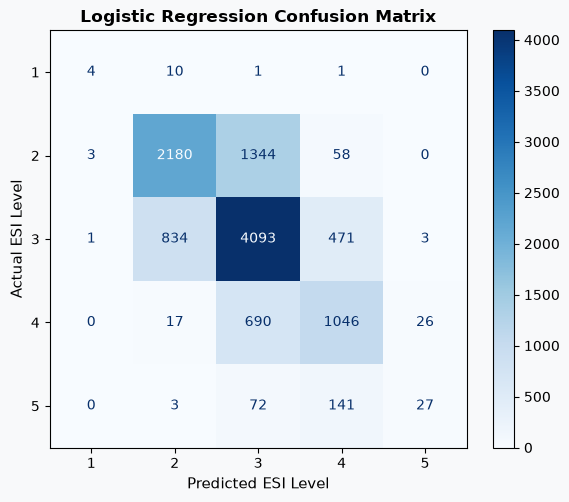

              precision    recall  f1-score   support

           1      0.500     0.250     0.333        16
           2      0.716     0.608     0.658      3585
           3      0.660     0.758     0.706      5402
           4      0.609     0.588     0.598      1779
           5      0.482     0.111     0.181       243

    accuracy                          0.667     11025
   macro avg      0.594     0.463     0.495     11025
weighted avg      0.666     0.667     0.661     11025



In [9]:
# CONFUSION MATRIX AND SAVING THE MODEL INTO FIGS FOLDER

os.makedirs("figs", exist_ok=True)
print(os.getcwd())

fig, ax = plt.subplots(figsize=(6,5), facecolor="#F8F9FA")

ConfusionMatrixDisplay.from_predictions(
    e_test, #  actual ESI values
    predict_logreg, # predicts the ESI values
    ax=ax, # displays the confusion matrix
    cmap="Blues"
)

ax.set_title(
    "Logistic Regression Confusion Matrix", # adds a title to the plot
    fontsize=12,
    fontweight="bold"
    ) 
ax.set_xlabel("Predicted ESI Level", fontsize=11)
ax.set_ylabel("Actual ESI Level", fontsize=11)

plt.tight_layout()
plt.savefig("figs/confusion_matrix.png", dpi=110, facecolor=fig.get_facecolor())
plt.show()

print(classification_report(e_test, predict_logreg, digits=3))


In [10]:
# COMPARING SCORES

# MACRO AND WEIGHTED SCORES 

macro_f1 = f1_score(e_test, predict_logreg, average="macro") #calculates the macro score
weighted_f1 = f1_score(e_test, predict_logreg, average="weighted") # calculates the weighted score

print("The Macro F1 Score:", round(macro_f1, 3)) # displays the macro score
print("The weighted F1 Score:", round(weighted_f1, 3)) # displays the weighted score


# ESI RECALL SCORE COMPARISON

tree_predict = tree.predict(P_test) # predicts the ESI using decision trees

logreg_recall = recall_score(
    e_test, # actual esi levels
    predict_logreg, # predicted esi levels
    labels=[1], # calculates for ESI level 1 only
    average=None
)[0]

tree_recall = recall_score(
    e_test, # actual esi levels
    tree_predict, # decision tree predictions
    labels=[1], # calculates for ESI level 1 only
    average=None
)[0]

print("Logistic Regression Recall:", round(logreg_recall, 3)) # displays the logistic regression recall
print("Decision Tree Recall:", round(tree_recall, 3)) # displays the decision tree recall



The Macro F1 Score: 0.495
The weighted F1 Score: 0.661
Logistic Regression Recall: 0.25
Decision Tree Recall: 0.0


In [11]:
# COMPARING THE MODEL AT A GLANCE

def summarise(name, preds):
    return {
        "model" : name,
        "accuracy" : round((preds == e_test).mean(), 3),
        "macro_f1" : round(f1_score(e_test, preds, average="macro"), 3),
        "recall_ESI_LEVEL1" : round(recall_score(e_test, preds, labels=[1], average=None)[0], 3),
    }

table = pd.DataFrame([
     summarise("Dummy (baseline)", dummy.predict(P_test)),
    summarise("Logistic Regression", predict_logreg),
    summarise("Decision Tree", tree.predict(P_test)),
])
table

,model,accuracy,macro_f1,recall_ESI_LEVEL1
0,Dummy (baseline),0.375,0.204,0.00
1,Logistic Regression,0.667,0.495,0.25
2,Decision Tree,0.556,0.216,0.00


# What this notebook entails

- uses the same dataset with demographic features removed except age
- reuses the same train and test split as well as preprocessing from the classification notebook so the results can be compared fairly
- evaluates the model using the confusion matrix, classification reports, recall and F1 scores.

## Key Results
- **Accuracy:**     0.667
- **ESI 1 Recall:** 0.250
- **ESI 2 Recall:** 0.608 
- **ESI 3 Recall:** 0.758
- **ESI 4 Recall:** 0.588
- **ESI 5 Recall:** 0.111

## Sumamry 
- **The Macro F1 Score: 0.495**, showed a weaker performance on less common ESI levels.
- **The weighted F1 Score: 0.661**  reflected the more common ESI 2 and 3 patients.
- **Logistic Regression Recall: 0.25** performed better than the decision tree and the dummy baseline, however it did struggle to identify ESI level 1 patients. This means that it can be more useful as a risk flag than a triage decision tool. 

# What does the Logistic Regression Confusion Matrix Tell Us?
The model spreads its predictions across all 5 ESI levels instead of relying entirely on ESI level 3. It identifies patients in all classes but struggles with the rare cases. 

# What does the Decision Tree Confusion Matrix Tell Us?
The model prdicts patients as ESI level 3 regardless of the actual ESI assigned level during triage. While it identifies ESI 3 patients, it completely misses the others. This shows that the model predicted the most common classes rather than distinguishing between the different ESI levels. 

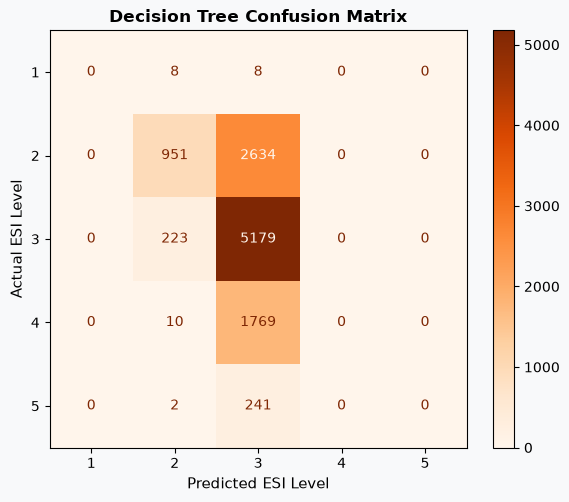

In [12]:
# EXERCISE ANSWERS
# QUESTION 1 - CONFUSION MATRIX FOR DECISION TREE

fig, ax = plt.subplots(figsize=(6,5), facecolor="#F8F9FA")
ConfusionMatrixDisplay.from_predictions(
    e_test,
    tree_predict,
    ax=ax,
    cmap="Oranges"
)

ax.set_title("Decision Tree Confusion Matrix", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted ESI Level", fontsize=11)
ax.set_ylabel("Actual ESI Level", fontsize=11)

plt.tight_layout()
plt.savefig("figs/Confusion_matrix_decision_tree.png", dpi=100, facecolor=fig.get_facecolor())
plt.show()

2. Logistic regression, the ES1 level 1 recall was 0.25 in comparision to the decision tree which was 0.0. The tree misses every single high level 1 patients in the test set.

3. Accuracy measures how often the model is right overall, but most patients aren't urgent. This means the model can score getting the common, low risk cases while still missing the critical care patients.